In [40]:
import os
import random
import shutil
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from PIL import Image

# Define paths to your images and labels folders
images_folder = '/Users/karthikpatralapati/Downloads/lab1data/images'
labels_folder = '/Users/karthikpatralapati/Downloads/lab1data/labels'

# Define paths for train and validation folders
train_images_folder = 'train_images/'
train_labels_folder = 'train_labels/'
val_images_folder = 'validation_images/'
val_labels_folder = 'validation_labels/'

# Define transformations for data augmentation
data_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.ToTensor(),
])

# Custom dataset class to load and transform images
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, image_folder, label_folder, transform=None):
        self.image_folder = image_folder
        self.label_folder = label_folder
        self.transform = transform
        self.image_files = os.listdir(image_folder)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = os.path.join(self.image_folder, self.image_files[idx])
        label_name = os.path.splitext(self.image_files[idx])[0] + '.xml'
        image = Image.open(img_name).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, os.path.join(self.label_folder, label_name)

# Create train and validation datasets
full_dataset = CustomDataset(images_folder, labels_folder, transform=data_transforms)

# Split data into train and validation sets
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

# Create train and validation loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Move images and labels to train and validation folders
def move_data(dataset, images_destination, labels_destination):
    os.makedirs(images_destination, exist_ok=True)
    os.makedirs(labels_destination, exist_ok=True)
    for i, (image, label) in enumerate(dataset):
        image_name = str(i) + '.jpg'  # Generating unique image names
        label_name = str(i) + '.xml'  # Generating unique label names
        image_path = os.path.join(images_destination, image_name)
        label_path = os.path.join(labels_destination, label_name)
        image_pil = transforms.ToPILImage()(image)  # Convert tensor to PIL Image
        image_pil.save(image_path)
        shutil.copy(label, label_path)

move_data(train_loader.dataset, train_images_folder, train_labels_folder)
move_data(val_loader.dataset, val_images_folder, val_labels_folder)


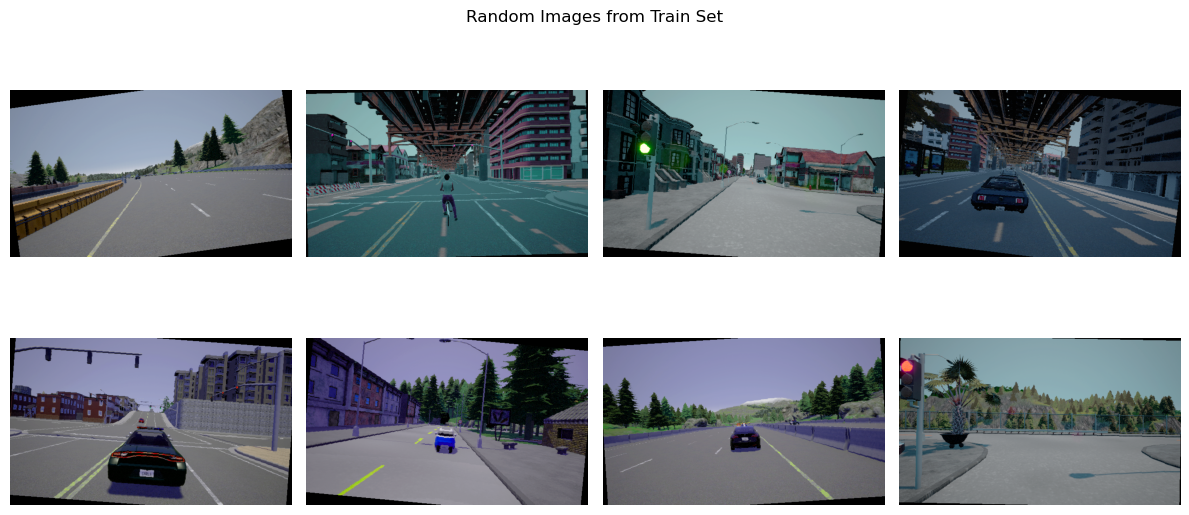

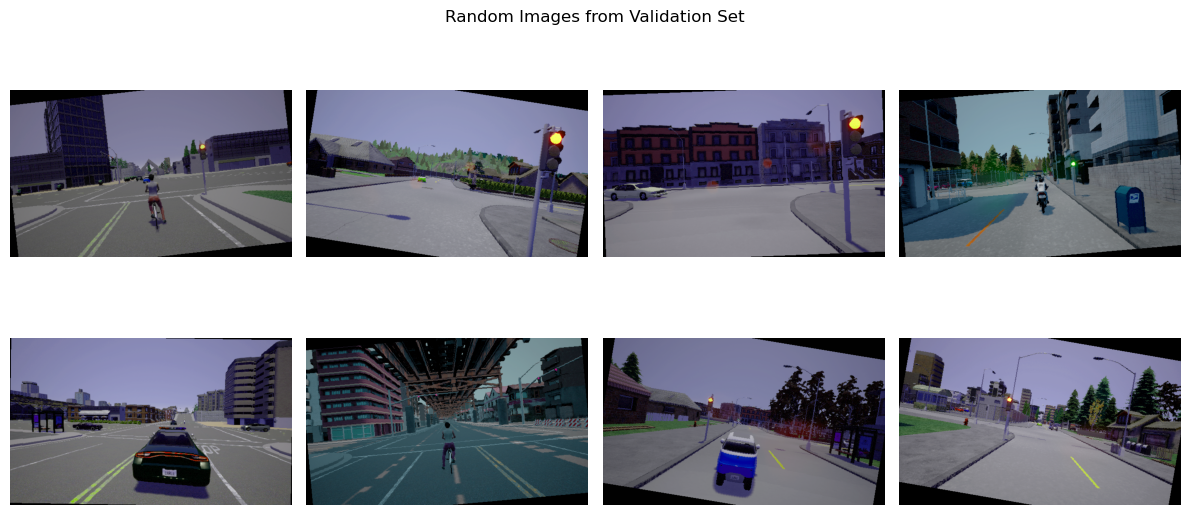

In [41]:
# Visualize random images from train set
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 6))
for ax in axes.flatten():
    rand_idx = random.randint(0, len(train_loader.dataset) - 1)
    image, _ = train_loader.dataset[rand_idx]
    image = transforms.ToPILImage()(image)  # Convert tensor to PIL Image
    ax.imshow(image)
    ax.axis('off')
plt.tight_layout()
plt.suptitle('Random Images from Train Set')
plt.show()

# Visualize random images from validation set
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 6))
for ax in axes.flatten():
    rand_idx = random.randint(0, len(val_loader.dataset) - 1)
    image, _ = val_loader.dataset[rand_idx]
    image = transforms.ToPILImage()(image)  # Convert tensor to PIL Image
    ax.imshow(image)
    ax.axis('off')
plt.tight_layout()
plt.suptitle('Random Images from Validation Set')
plt.show()